In [28]:
from sklearn.datasets import load_breast_cancer
import pandas as pd

brest_cancer = load_breast_cancer()
df = pd.DataFrame(brest_cancer.data, columns=brest_cancer.feature_names)
target = pd.Series(brest_cancer.target)

print(df.describe())
print(target.value_counts())

       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0.000000             0.000000   
25%      

In [29]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(df, target, test_size=0.3, stratify=target, random_state=42)

In [30]:
import optuna 
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer, fbeta_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import cross_val_score

scorer = make_scorer(fbeta_score, beta=2, pos_label=1, average='binary')

optuna.logging.set_verbosity(optuna.logging.WARNING)

def objective(trial):
    
    kernel =  trial.suggest_categorical('kernel', ['rbf', 'linear', 'poly', 'sigmoid'])
    #kernel =  trial.suggest_categorical('kernel', ['rbf'])
    C = trial.suggest_float('C', 1e-3, 100, log=True)
    gamma = trial.suggest_float('gamma', 1e-4, 1, log=True)
    random_state = trial.suggest_categorical('random_state', [42])

    # default
    degree = 3
    coef0 = 0.0

    if kernel == 'poly':
        degree = trial.suggest_int('degree', 2, 5)
        coef0 = trial.suggest_float('coef0', 0.0, 1.0)
    elif kernel == 'sigmoid':
        coef0 = trial.suggest_float('coef0', -1.0, 1.0)

    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])

    model = make_pipeline(
        StandardScaler(),
        SVC(
            kernel=kernel,
            C=C,
            gamma=gamma,
            degree=degree,
            coef0=coef0,
            class_weight=class_weight,
            random_state=random_state
        )
    )

    return cross_val_score(model, x_train, y_train, cv=5, scoring=scorer).mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=1000, show_progress_bar=True)
print(study.best_params)

Best trial: 31. Best value: 0.993644: 100%|██████████| 1000/1000 [00:58<00:00, 17.08it/s]

{'kernel': 'linear', 'C': 0.017858544707440718, 'gamma': 0.019209879015742944, 'random_state': 42, 'class_weight': None}


Accuracy: 0.9707602339181286
              precision    recall  f1-score   support

           0       0.98      0.94      0.96        64
           1       0.96      0.99      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



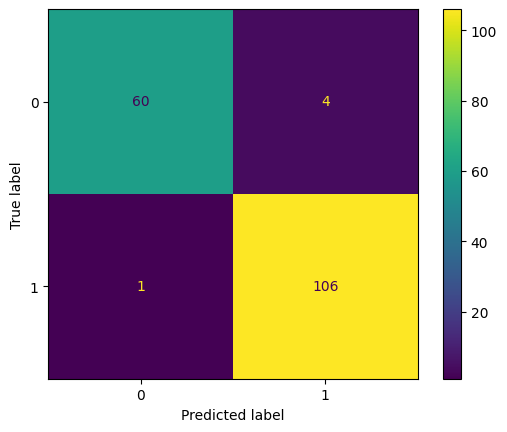

In [31]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

bp = study.best_params

final_model = make_pipeline(
    StandardScaler(),
    SVC(
        kernel=bp["kernel"],
        C=bp["C"],
        gamma=bp["gamma"],
        degree=bp.get("degree", 3),
        coef0=bp.get("coef0", 0.0),
        class_weight=bp["class_weight"],
        random_state=bp["random_state"]
    )
)

final_model.fit(x_train, y_train)

y_pred = final_model.predict(x_test)

print("Accuracy:", final_model.score(x_test, y_test))
print(classification_report(y_test, y_pred))
ConfusionMatrixDisplay.from_estimator(final_model, x_test, y_test)

Accuracy 2D PCA: 0.9181286549707602


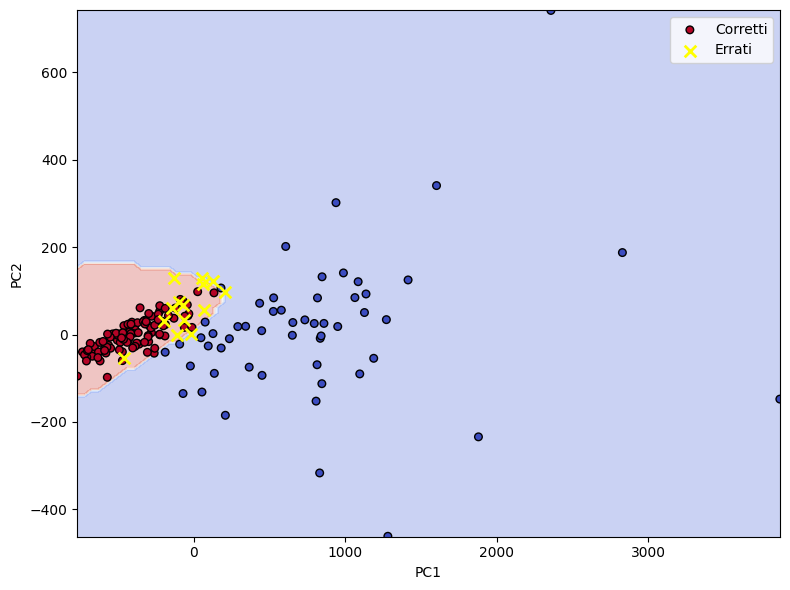

In [40]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.inspection import DecisionBoundaryDisplay

# 1) PCA a 2 componenti su train, applicata anche al test
pca = PCA(n_components=2, random_state=42)
X_train_2d = pca.fit_transform(x_train)
X_test_2d = pca.transform(x_test)

# 2) SVM nello spazio 2D (puoi mettere i best_params che vuoi)
svm_2d = make_pipeline(
    StandardScaler(),
    SVC(
        kernel='rbf',      # oppure 'linear' o i parametri trovati con Optuna
        C=1.0,
        gamma='scale',
        random_state=42
    )
)

svm_2d.fit(X_train_2d, y_train)
print("Accuracy 2D PCA:", svm_2d.score(X_test_2d, y_test))

# 3) Predizioni sul test per identificare errori
y_test_pred = svm_2d.predict(X_test_2d)
errors = y_test_pred != y_test

# 4) Decision boundary + punti corretti / errati
fig, ax = plt.subplots(figsize=(8, 6))

disp = DecisionBoundaryDisplay.from_estimator(
    svm_2d,
    X_test_2d,
    response_method="predict",
    cmap="coolwarm",
    alpha=0.3,
    ax=ax
)

# punti test corretti
ax.scatter(
    X_test_2d[~errors, 0],
    X_test_2d[~errors, 1],
    c=y_test[~errors],
    cmap="coolwarm",
    s=30,
    edgecolor="k",
    label="Corretti"
)

# punti test errati evidenziati
ax.scatter(
    X_test_2d[errors, 0],
    X_test_2d[errors, 1],
    c="yellow",
    marker="x",
    s=70,
    linewidths=2,
    label="Errati"
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend()
plt.tight_layout()
plt.show()